### GRU

在实际工程中，RNN有个致命弱点，即它的记忆力非常短。在处理长序列时，早期的信息在反向传播中会因为连乘效应导致梯度消失，模型会把开头的细节忘光

#### 一、带“开关”的记事本
RNN可以想象成一个不停重写的记事本，新信息辉覆盖旧信息。而GRU则给记事本安装了门控机制，用来保护重要的记忆
- 更新门：决定要从过去的记忆信号中保留多少，以及从当前的信息中吸收多少
- 重置门：决定在查看新信息时，多大程度忽略过去的记忆

#### 二、GRU内部运作
- 重置历史：利用重置门扫一眼过去的记忆。如果是处理一段新信息，会告诉模型”之前的上下文不重要了，清空一些“
- 提炼新知：将筛选后的记忆与当前输入结合，通过tanh激活函数生成一个候选记忆状态
- 博弈更新：更新门像是一个平衡秤，在旧记忆和新候选记忆之间权衡
- 最终输出：输出当前的隐藏状态，并传给下一个时间步
这种机制可以让GRU学会：如果某个信息很重要，就让更新门保持关闭，把这个信息一直瞬移到句子结束

#### 三、应用场景
- 中小规模时间序列预测：如股票日收盘价（100-200 天窗口）、电子产品销量预测。
- 语音识别中的声学建模：在实时性要求较高时，GRU 可取得与 LSTM 相近的精度但延迟更低。
- 自然语言处理中的情感分析：对短评论文本（如 Twitter 推文）进行分类。
- 机器翻译的轻量编码器：资源受限环境下的端到端翻译模型。
- 音乐生成与和弦识别：捕捉小节级别的音乐模式。

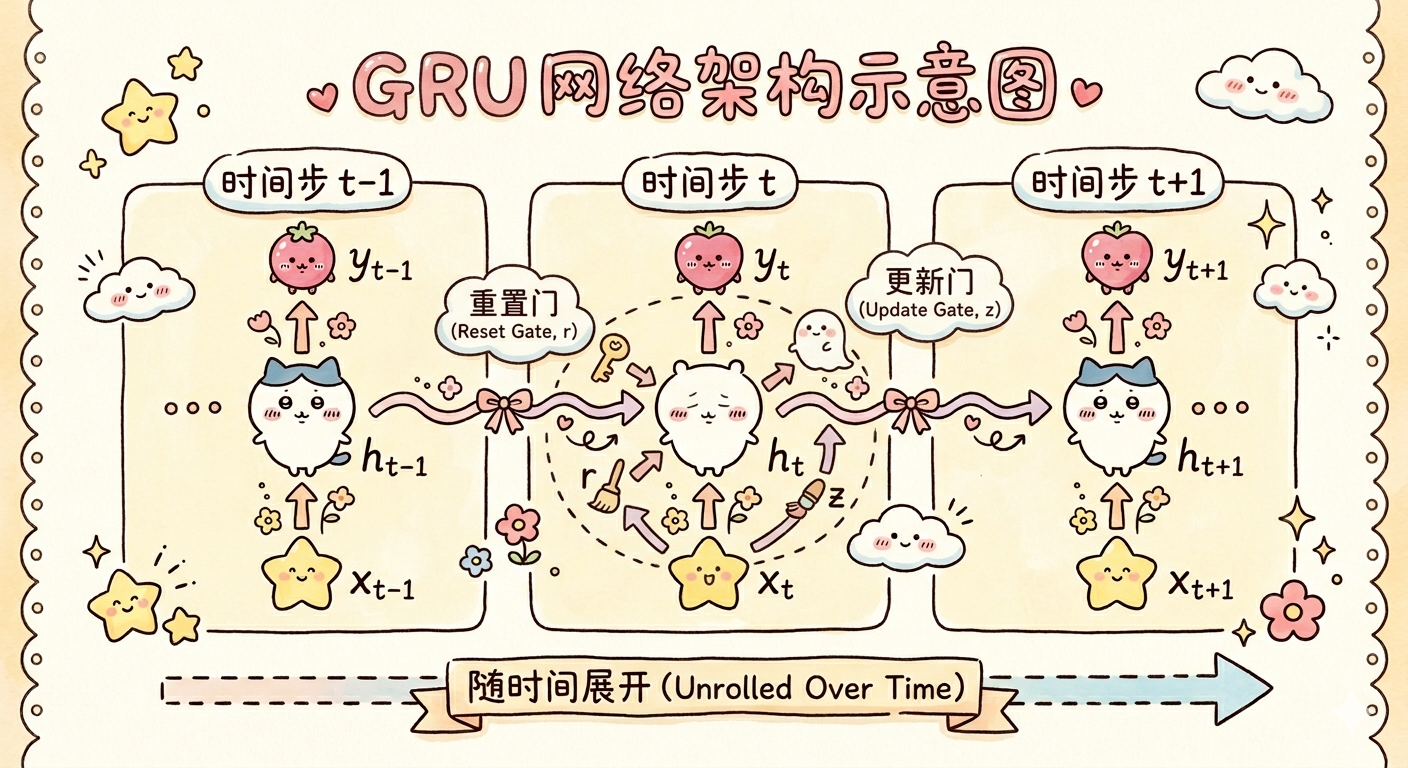

#### 案例：预测电力负荷
- 数据集：ETTH1
- 该数据集通常包含电力系统的多种变量，包括价格、电力负荷、天气情况等。这些变量可以用来预测未来的电力需求或价格
- 该数集通常按小时或者天记录

In [3]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 设置随机种子，保证可复现性
np.random.seed(0)
torch.manual_seed(0)

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        seq, label = self.sequences[index]
        # 增加特征维度: (seq_len, 1) 和 (pred_len, 1)
        return (torch.tensor(seq, dtype=torch.float32).unsqueeze(-1),
                torch.tensor(label, dtype=torch.float32).unsqueeze(-1))

In [5]:
def calculate_metrics(y_true, y_pred):
    """
    计算回归指标: MAE, MSE, RMSE, R²
    y_true, y_pred: 一维 numpy 数组
    """
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


def create_sequences(data, input_window, pred_len):
    """
    将原始时间序列转换为监督学习所需的 (输入序列, 标签序列) 对
    data: 归一化后的 1D 数组或列表
    input_window: 输入序列长度
    pred_len: 预测序列长度
    """
    sequences = []
    L = len(data)
    for i in range(L - input_window - pred_len + 1):
        train_seq = data[i:i + input_window]
        train_label = data[i + input_window:i + input_window + pred_len]
        sequences.append((train_seq, train_label))
    return sequences

#### 手写GRU架构

In [ ]:

"""
class ManualGRU(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1, output_dim=1, pre_len=4):
        super(ManualGRU, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim
        self.pre_len = pre_len

        # 为每一层创建独立的GRU参数
        self.gru_params = nn.ModuleList()
        for l in range(num_layers):
            layer_input_dim = input_dim if l == 0 else hidden_dim
            layer = GRUCellLayer(layer_input_dim, hidden_dim)
            self.gru_params.append(layer)

        # 层间 dropout（多层时使用）
        self.dropout = nn.Dropout(0.1)
        # 输出层：将 hidden_dim 映射到 output_dim
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        batch_size, seq_len, _ = x.shape
        device = x.device

        # 存储每一层输出的所有时间步（用于层间传递）
        layer_outputs = []

        # 当前层输入 = 原始输入
        current_input = x

        for l in range(self.num_layers):
            # 初始化当前层的隐藏状态 h0: (batch, hidden_dim)
            h_t = torch.zeros(batch_size, self.hidden_dim, device=device)

            # 存储当前层每个时间步的输出
            out_seq = []

            # 按时间步循环
            for t in range(seq_len):
                x_t = current_input[:, t, :]          # (batch, input_dim)
                h_t = self.gru_params[l](x_t, h_t)    # (batch, hidden_dim)
                out_seq.append(h_t)

            # 将时间步堆叠成序列: (batch, seq_len, hidden_dim)
            current_output = torch.stack(out_seq, dim=1)

            # 如果不是最后一层，对输出施加 dropout
            if l < self.num_layers - 1:
                current_output = self.dropout(current_output)

            # 当前层的输出作为下一层的输入
            current_input = current_output

        # 最终输出为最后一层的完整序列
        out = current_output  # (batch, seq_len, hidden_dim)

        # 取最后 pre_len 个时间步
        out = out[:, -self.pre_len:, :]   # (batch, pre_len, hidden_dim)

        # 全连接 + ReLU
        out = self.fc(out)                # (batch, pre_len, output_dim)
        out = self.relu(out)
        return out
"""

"""
class GRUCellLayer(nn.Module):
    #单个 GRU 层（单层，所有时间步共享参数）
    def __init__(self, input_dim, hidden_dim):
        super(GRUCellLayer, self).__init__()
        self.hidden_dim = hidden_dim

        # 更新门参数
        self.W_z = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_z = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # 重置门参数
        self.W_r = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_r = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # 候选隐藏状态参数
        self.W_h = nn.Linear(input_dim, hidden_dim, bias=True)
        self.U_h = nn.Linear(hidden_dim, hidden_dim, bias=False)


    def forward(self, x_t, h_prev):
        ###
        x_t:   (batch, input_dim)
        h_prev: (batch, hidden_dim)
        returns: h_t (batch, hidden_dim)
        # 更新门
        z_t = torch.sigmoid(self.W_z(x_t) + self.U_z(h_prev))
        # 重置门
        r_t = torch.sigmoid(self.W_r(x_t) + self.U_r(h_prev))
        # 候选隐藏状态
        h_tilde = torch.tanh(self.W_h(x_t) + self.U_h(r_t * h_prev))
        # 最终隐藏状态
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        return h_t
"""

#### pytorch官方

In [6]:
class GRUNet(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1, output_dim=1, pred_len=5, dropout=0.1):
        super(GRUNet, self).__init__()
        self.pred_len = pred_len
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)                     # (batch, seq_len, hidden_dim)
        out = self.dropout(out)
        out = out[:, -self.pred_len:, :]             # (batch, pred_len, hidden_dim)
        out = self.fc(out)                           # (batch, pred_len, output_dim)
        out = self.relu(out)
        return out

In [7]:
def train_model(model, train_loader, val_loader, epochs, lr, patience=5, model_save_path='best_model.pth'):
    """
    训练模型，保存验证集上损失最小的最佳模型，支持早停
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience_counter = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # 训练阶段
        model.train()
        epoch_train_loss = 0.0
        for seq, labels in train_loader:
            seq, labels = seq.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(seq)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * seq.size(0)

        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # 验证阶段
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for seq, labels in val_loader:
                seq, labels = seq.to(device), labels.to(device)
                output = model(seq)
                loss = criterion(output, labels)
                epoch_val_loss += loss.item() * seq.size(0)

        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

        # 保存最佳模型
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), model_save_path)
            patience_counter = 0
            print(f"  -> 保存最佳模型 (val_loss={best_val_loss:.6f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"早停于 epoch {epoch+1}")
                break

    # 加载最佳模型参数
    model.load_state_dict(torch.load(model_save_path))
    return model, train_losses, val_losses

In [8]:
def evaluate_model(model, test_loader, scaler):
    """在测试集上评估模型，返回反标准化后的真实值和预测值，以及包含各项指标的字典"""
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for seq, labels in test_loader:
            seq, labels = seq.to(device), labels.to(device)
            output = model(seq)                     # (batch, pred_len, 1)
            # 转移到CPU并转为numpy
            pred_batch = output.cpu().numpy()
            true_batch = labels.cpu().numpy()
            # 展平每个样本的预测序列（保留顺序）
            preds.extend(pred_batch.reshape(-1, 1))
            trues.extend(true_batch.reshape(-1, 1))

    # 反标准化
    preds = scaler.inverse_transform(np.array(preds))
    trues = scaler.inverse_transform(np.array(trues))
    trues = trues.flatten()
    preds = preds.flatten()

    # 计算各项指标
    metrics = calculate_metrics(trues, preds)
    return trues, preds, metrics


In [9]:
def predict_future(model, last_sequence, steps, input_window, pred_len, scaler):
    """
    使用训练好的模型递归预测未来多个时间步
    last_sequence: 最后 input_window 个历史值（原始尺度，未标准化）
    steps: 要预测的总步数
    """
    model.eval()
    # 将最后的历史数据标准化
    last_seq_norm = scaler.transform(last_sequence.reshape(-1, 1)).flatten()
    future_preds = []

    current_input = last_seq_norm.tolist()   # 长度 = input_window

    while len(future_preds) < steps:
        # 准备当前输入 (1, input_window, 1)
        input_tensor = torch.tensor(current_input[-input_window:], dtype=torch.float32).view(1, input_window, 1).to(device)
        with torch.no_grad():
            pred = model(input_tensor)          # (1, pred_len, 1)
        pred = pred.cpu().numpy().flatten()     # 长度为 pred_len

        # 取需要的步数（避免超出）
        need = steps - len(future_preds)
        take = min(pred_len, need)
        future_preds.extend(pred[:take])

        # 将本次预测结果作为后续输入的一部分（滑动窗口）
        current_input.extend(pred)

    # 反标准化
    future_preds = np.array(future_preds).reshape(-1, 1)
    future_preds = scaler.inverse_transform(future_preds).flatten()
    return future_preds


原始数据长度: 17420
训练集: 10452 | 验证集: 3484 | 测试集: 3484
训练样本数: 10416 | 验证样本数: 3448 | 测试样本数: 3448
GRUNet(
  (gru): GRU(1, 32, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
)
Epoch   1/20 | Train Loss: 0.007172 | Val Loss: 0.001651
  -> 保存最佳模型 (val_loss=0.001651)
Epoch   2/20 | Train Loss: 0.002983 | Val Loss: 0.000844
  -> 保存最佳模型 (val_loss=0.000844)
Epoch   3/20 | Train Loss: 0.002674 | Val Loss: 0.001094
Epoch   4/20 | Train Loss: 0.002333 | Val Loss: 0.000783
  -> 保存最佳模型 (val_loss=0.000783)
Epoch   5/20 | Train Loss: 0.002100 | Val Loss: 0.000763
  -> 保存最佳模型 (val_loss=0.000763)
Epoch   6/20 | Train Loss: 0.002046 | Val Loss: 0.000853
Epoch   7/20 | Train Loss: 0.001962 | Val Loss: 0.001882
Epoch   8/20 | Train Loss: 0.001940 | Val Loss: 0.000751
  -> 保存最佳模型 (val_loss=0.000751)
Epoch   9/20 | Train Loss: 0.001892 | Val Loss: 0.000783
Epoch  10/20 | Train Loss: 0.001958 | Val Lo

C:\Users\23017\AppData\Local\Temp\ipykernel_34796\1829011219.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))



========== 测试集评估结果 ==========
MAE: 1.0290
MSE: 1.9904
RMSE: 1.4108
R2: 0.8321


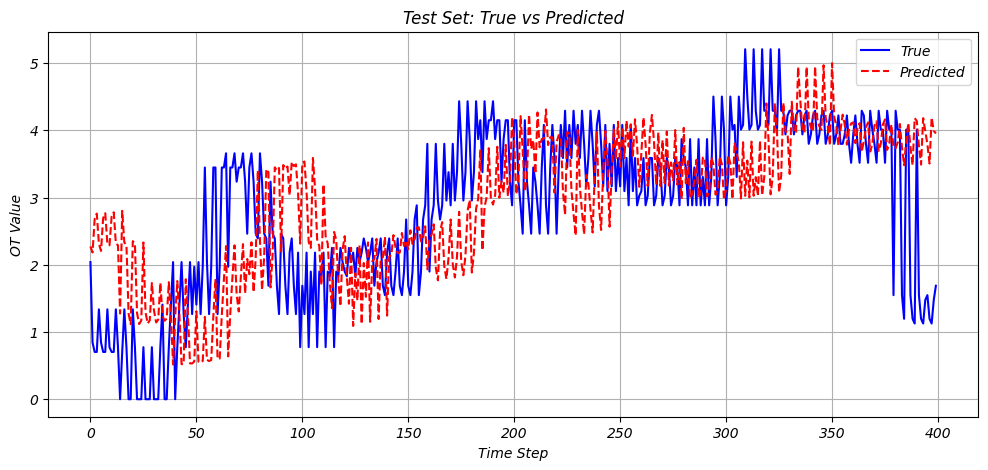


========== 未来30步预测评估结果 ==========
MAE: 1.2320
MSE: 2.0625
RMSE: 1.4362
R2: -1.0879


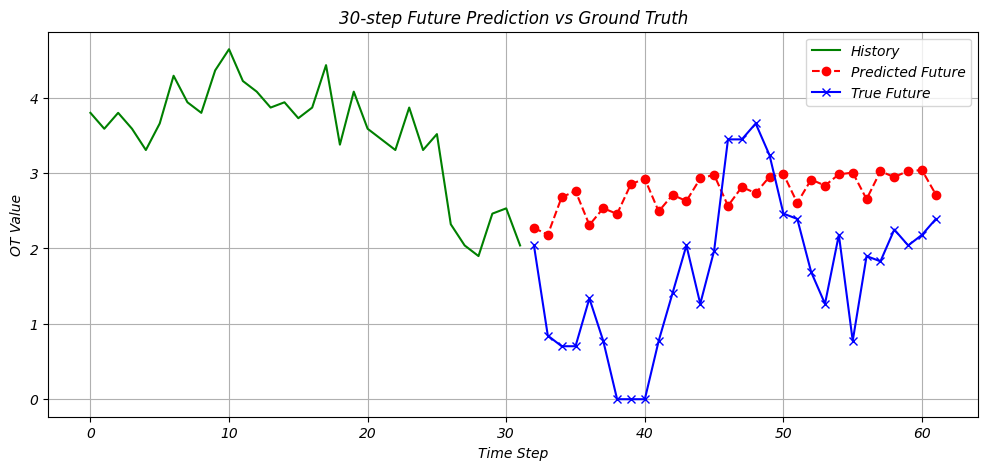

In [10]:
def main():
 
    df = pd.read_csv('./ETTh1.csv')
    target = 'OT'
    data_raw = df[target].values.reshape(-1, 1)
    print(f"原始数据长度: {len(data_raw)}")

   
    total_len = len(data_raw)
    train_ratio, val_ratio, test_ratio = 0.6, 0.2, 0.2
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))

    train_data = data_raw[:train_end]
    val_data = data_raw[train_end:val_end]
    test_data = data_raw[val_end:]

    print(f"训练集: {len(train_data)} | 验证集: {len(val_data)} | 测试集: {len(test_data)}")

  
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_data)
    val_norm = scaler.transform(val_data)
    test_norm = scaler.transform(test_data)


    input_window = 32
    pred_len = 5

    train_seq = create_sequences(train_norm.flatten(), input_window, pred_len)
    val_seq = create_sequences(val_norm.flatten(), input_window, pred_len)
    test_seq = create_sequences(test_norm.flatten(), input_window, pred_len)

    print(f"训练样本数: {len(train_seq)} | 验证样本数: {len(val_seq)} | 测试样本数: {len(test_seq)}")

    batch_size = 32
    train_loader = DataLoader(TimeSeriesDataset(train_seq), batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(TimeSeriesDataset(val_seq), batch_size=batch_size, shuffle=False, drop_last=True)
    test_loader = DataLoader(TimeSeriesDataset(test_seq), batch_size=batch_size, shuffle=False, drop_last=True)

  
    model = GRUNet(input_dim=1, hidden_dim=input_window, num_layers=2,
                   output_dim=1, pred_len=pred_len, dropout=0.1).to(device)
    print(model)


    epochs = 20
    lr = 0.005
    start_time = time.time()
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs, lr,
                                                   patience=5, model_save_path='best_gru_model.pth')
    print(f"训练完成，最佳模型已保存，用时: {(time.time() - start_time) / 60:.2f} 分钟")


    trues, preds, test_metrics = evaluate_model(model, test_loader, scaler)
    print("\n========== 测试集评估结果 ==========")
    for metric_name, value in test_metrics.items():
        print(f"{metric_name}: {value:.4f}")

   
    plt.figure(figsize=(12, 5))
    plt.plot(trues[:400], label='True', color='blue')
    plt.plot(preds[:400], label='Predicted', color='red', linestyle='--')
    plt.title('Test Set: True vs Predicted')
    plt.xlabel('Time Step')
    plt.ylabel('OT Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 为了验证，我们使用测试集的起始部分：取最后 input_window 个已知值作为初始序列，
    # 预测接下来的30步，并与测试集中的真实值对比。
    test_len = len(test_norm)
    if test_len >= input_window + 30:
        # 取测试集开头的一段作为初始窗口
        start_idx = 0
        last_real = test_data[start_idx:start_idx + input_window].flatten()  # 原始尺度
        # 真实未来30步
        true_future = test_data[start_idx + input_window:start_idx + input_window + 30].flatten()
    else:
        # 若测试集长度不够，则从原始数据末尾取
        print("测试集长度不足，改用整体数据末尾段进行预测验证")
        last_real = data_raw[-input_window:].flatten()
        # 真实未来30步（如果存在）
        if len(data_raw) >= input_window + 30:
            true_future = data_raw[-input_window - 30:-input_window].flatten()
        else:
            true_future = None
            print("数据总长度不足，无法获取真实未来30步，仅展示预测曲线")

    future_steps = 30
    future_pred = predict_future(model, last_real, future_steps, input_window, pred_len, scaler)

    # 如果有真实值，计算未来预测的指标
    if true_future is not None:
        # 确保长度一致（可能预测步数超过真实值长度，取前 len(true_future) 个）
        pred_aligned = future_pred[:len(true_future)]
        future_metrics = calculate_metrics(true_future, pred_aligned)
        print("\n========== 未来30步预测评估结果 ==========")
        for metric_name, value in future_metrics.items():
            print(f"{metric_name}: {value:.4f}")
    else:
        future_metrics = None

    # 绘制预测结果对比图
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(last_real)), last_real, label='History', color='green')
    plt.plot(range(len(last_real), len(last_real) + future_steps), future_pred,
             label='Predicted Future', color='red', linestyle='--', marker='o')
    if true_future is not None:
        plt.plot(range(len(last_real), len(last_real) + len(true_future)), true_future,
                 label='True Future', color='blue', linestyle='-', marker='x')
    plt.title('30-step Future Prediction vs Ground Truth')
    plt.xlabel('Time Step')
    plt.ylabel('OT Value')
    plt.legend()
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    main()